In [ ]:
# ==========================================
# Jupyter Magic Commands & Core Imports
# ==========================================
# Enable interactive matplotlib plots
%matplotlib widget

# Load the autoreload extension to automatically update custom modules
%load_ext autoreload
# Set autoreload to update modules every time a cell is executed
%autoreload 2

import numpy as np
from numba import njit
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Line3D
import matplotlib.animation as animation
import os

# ==========================================
# Custom Modules Import
# ==========================================

from densification import NJIT_syncr_measure_time,  NJIT_bloch_coords, NJIT_vectors_inCartesian_coords
import visualization 
# import nonmarkovian

## Data Load

In [2]:
# ====================================
# Physical & Simulation Parameters
# ====================================
# Theta angle in degrees, H_Coll Direction
theta_target_deg = 0.0  # change angle here
theta_rad = np.radians(theta_target_deg)

# Site selector: 0 for |10>, 1 for |01>
site_index = 0

# Time step
dt = 0.01

# Number of trajectories to analyze
N_traj_to_plot = 100         

# =================
# Input Data Setup
# =================
Input_dir = "../../Results/Data/Complete_rho/normal"  # <-- change here if needed

# Format theta and dt for filename 
theta_str = f"{theta_rad:.6f}".replace(".", "p")
dt_str = f"{dt:.6f}".replace(".", "p")

# File name
filename = f"result_theta{theta_str}_dt{dt_str}_Ntraj20000.npz"
filepath = os.path.join(Input_dir, filename)

print(f"Analisi impostata per theta = {theta_target_deg}°")
print(f"File target: {filename}")

if not os.path.exists(filepath):
    print(f"ERRORE: The file {filepath} doesn't exist. Check file name.")
else:
    # Load .npz input containing data
    data = np.load(filepath)
    
    times= data['times']

    # Define a downsampling factor (e.g., take 1 every 10 time steps)
    time_downsample_factor = 1
    
    # Downsample the time array
    time_stepped = times[::time_downsample_factor]
    N_time = len(time_stepped)
    
    print("Matrix extraction and downsampling in progress")
    
    # ================================
    # Raw Trajectories Extraction
    # ================================
    
    # Extract the full time array
    full_times = data['times']
    
    # Extract and downsample the raw trajectories along the time axis (axis 0)
    # Then transpose (.T) to get the expected (N_traj, N_time) shape
    pop_traj_10 = data['pop_00'][::time_downsample_factor, :].T
    pop_traj_01 = data['pop_11'][::time_downsample_factor, :].T
    
    cohe_traj_10_01 = data['coh_10_01'][::time_downsample_factor, :].T
    cohe_traj_01_10 = data['coh_01_10'][::time_downsample_factor, :].T

    # Extract real and imaginary parts of the coherence
    rho12_re = np.real(cohe_traj_10_01)
    rho12_im = np.imag(cohe_traj_10_01)
    
    # Map populations to density matrix diagonal elements
    rho11 = pop_traj_10
    rho22 = pop_traj_01

    print("Data extraction completed")

# ── Ricostruzione delle matrici densità 2x2 ──────────────────────────────
#
#   rho = [[rho11,        rho12_re + i*rho12_im],
#           [rho12_re - i*rho12_im, rho22       ]]
#
N_traj, N_time = rho11.shape

many_rho = np.zeros((N_traj, N_time, 2, 2), dtype=complex)
many_rho[:, :, 0, 0] =  rho11
many_rho[:, :, 1, 1] =  rho22
many_rho[:, :, 0, 1] =  rho12_re + 1j * rho12_im
many_rho[:, :, 1, 0] =  rho12_re - 1j * rho12_im

print(f"Shape many_rho: {many_rho.shape}")
print(f"Esempio rho[traj=0, t=0]:\n{many_rho[0,0]}")
print(f"Traccia (deve essere ~1): {np.real(np.trace(many_rho[0,0])):.4f}")

Analisi impostata per theta = 0.0°
File target: result_theta0p000000_dt0p010000_Ntraj20000.npz
Matrix extraction and downsampling in progress
Data extraction completed
Shape many_rho: (20000, 10000, 2, 2)
Esempio rho[traj=0, t=0]:
[[0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Traccia (deve essere ~1): 1.0000


In [3]:
# ===========================
# General Setup for Plotting
# ===========================
# --- 1. Output Directory---

if theta_target_deg.is_integer():
    angle_folder = str(int(theta_target_deg))
else:
    angle_folder = str(theta_target_deg)

Output_dir = os.path.join("../../Results/Plot/Densification", angle_folder)
os.makedirs(Output_dir, exist_ok=True)

# --- . Automatic Figure Saving Function ---
def save_fig(fig, filename):
    """
    Saves the figure in both PNG or PDF
    """
    path_png = os.path.join(Output_dir, f"{filename}.png")
    # path_pdf = os.path.join(Output_dir, f"{filename}.pdf")  # save in pdf
    
    fig.savefig(path_png, dpi=300, bbox_inches='tight')
    # fig.savefig(path_pdf, bbox_inches='tight') # save in pdf
    print(f"Figure saved in: {Output_dir}/{filename}")

## Densification Measure

In [4]:
# Define how many trajectories to use for the synchronization measure
# 1000 trajectories = ~500,000 pairs (400 times faster than 20,000!)
N_traj_sync = 10000

# Pass only the sliced array to the function
BF_syncr_meas = NJIT_syncr_measure_time(
    many_rho[:N_traj_sync],
    norm     = np.pi / 2,
    minusone = True
)

print(f"Measure calculated on {N_time} time steps, {N_traj_sync} trajectories.")
print(f"Initial value: {BF_syncr_meas[0]:.4f}   Final value: {BF_syncr_meas[-1]:.4f}")

Measure calculated on 1000 time steps, 10000 trajectories.
Initial value: 1.0000   Final value: 0.0000


Figure saved in: ../../Results/Plot/Densification/90/densification_measure_theta1p570796_dt0p010000_Ntraj10000


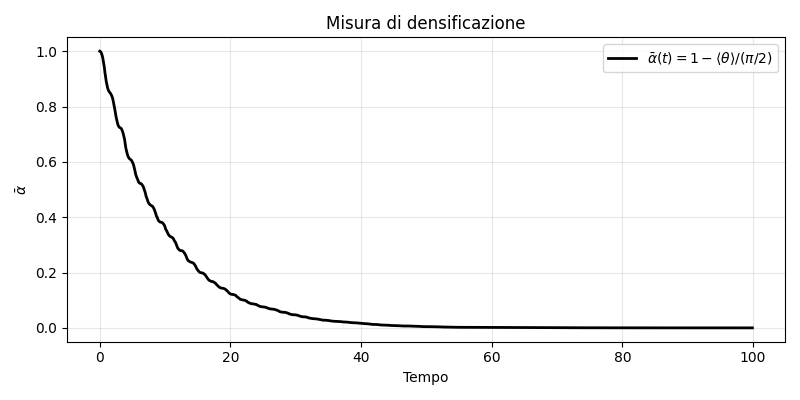

In [5]:
# ── Plot densificazione nel tempo ───

plt.close('all')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(time_stepped, BF_syncr_meas, color='k', lw=2, label=r'$\bar{\alpha}(t) = 1 - \langle\theta\rangle / (\pi/2)$')
ax.set_xlabel('Tempo')
ax.set_ylabel(r'$\bar{\alpha}$')
ax.set_title('Misura di densificazione')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

filename_dens = f"densification_measure_theta{theta_str}_dt{dt_str}_Ntraj{N_traj_sync}"
save_fig(fig, filename_dens)

plt.show()

## SVD Analysis

In [4]:
# Define the number of trajectories to use for the SVD analysis
N_traj_svd = 10000  # Number of trajectories to sample

sing_vals = []
V_list = []

for t in range(N_time):
    # 1. Extract Bloch vectors: shape (N_traj_svd, 3)
    vects = NJIT_vectors_inCartesian_coords(many_rho[:N_traj_svd], t_idx=t)
    
    # 2. Perform SVD on the (N, 3) matrix.
    # U is (N, 3) -> we discard it using '_' to prevent memory overflow.
    # S is (3,) -> these are the singular values (ellipsoid semi-axes lengths).
    # Vh is (3, 3) -> the rows of Vh are the principal axes of the ellipsoid.
    _, S, Vh = np.linalg.svd(vects, full_matrices=False)
    
    sing_vals.append(S)
    
    # 3. We append Vh.T (which is V) so that the columns of the stored 3x3 matrices 
    # represent the (x, y, z) coordinates of the principal axes in the Bloch sphere.
    V_list.append(Vh.T)

# Convert lists to NumPy arrays for plotting and analysis
sing_vals_list = np.array(sing_vals)  # Shape: (N_time, 3)
V_list = np.array(V_list)        # Shape: (N_time, 3, 3)

In [ ]:
@njit
def fast_svd_evolution(many_rho_subset):
    """
    Computes the SVD of Bloch vectors over time using preallocated arrays
    and compiling the entire time loop in C with Numba.
    """
    n_traj = many_rho_subset.shape[0]
    n_time = many_rho_subset.shape[1]
    
    # 1. Preallocate the final output arrays (much faster than list.append)
    sing_vals = np.empty((n_time, 3), dtype=np.float64)
    V_list = np.empty((n_time, 3, 3), dtype=np.float64)
    
    # 2. Preallocate the Cartesian vector matrix ONCE.
    # We will overwrite this memory at each time step, saving massive amounts of RAM and time.
    vects = np.empty((n_traj, 3), dtype=np.float64)
    
    for t in range(n_time):
        
        # Populate the vects array for the current time step
        for i in range(n_traj):
            rho = many_rho_subset[i, t]
            bloch_vec = NJIT_bloch_coords(rho) 
            vects[i, 0] = bloch_vec[0]
            vects[i, 1] = bloch_vec[1]
            vects[i, 2] = bloch_vec[2]
            
        # Perform SVD (Numba supports np.linalg.svd natively!)
        # Using full_matrices=False directly inside Numba
        _, S, Vh = np.linalg.svd(vects, full_matrices=False)
        
        # Store the singular values
        sing_vals[t, :] = S
        
        # Store the transposed Vh (which is V)
        # We manually transpose assigning elements to avoid memory copies in Numba
        for r in range(3):
            for c in range(3):
                V_list[t, c, r] = Vh[r, c]
                
    return sing_vals, V_list

# --- Execution ---

N_traj_svd = 10000

# Slice the trajectory array ONCE before passing it to the Numba function
many_rho_subset = many_rho[:N_traj_svd]

# Call the highly optimized function
sing_vals_list, V_list = fast_svd_evolution(many_rho_subset)

In [5]:
sing_vals_list.shape


(10000, 3)

### Plot Singular Values in time 

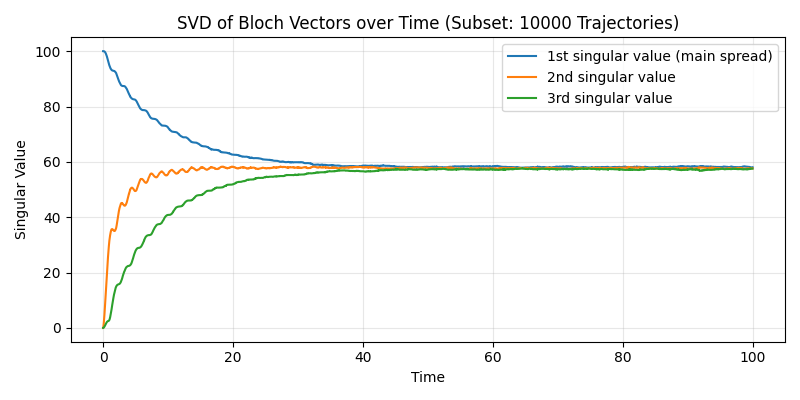

In [6]:
plt.close('all')

# ── Plot SVD Singular Values ─────
fig_svd, ax = plt.subplots(figsize=(8, 4))

labels_sv = ['1st singular value (main spread)',
             '2nd singular value',
             '3rd singular value']

# Loop through the 3 singular values and plot their time evolution
for k in range(3):
    ax.plot(time_stepped, sing_vals_list[:, k], label=labels_sv[k])

ax.set_xlabel('Time')
ax.set_ylabel('Singular Value')
ax.set_title(f'SVD of Bloch Vectors over Time (Subset: {N_traj_svd} Trajectories)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()

filename_svd = f"SVD_singular_values_theta{theta_str}_dt{dt_str}_Ntraj{N_traj_svd}"
#save_fig(fig_svd, filename_svd)

plt.show()

### Evolution in time of the 3 vectors representing the semiaxes of an ellipsoid

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
import imageio.v2 as imageio
import os

def create_bloch_svd_gif(sing_vals, V_list, N_traj, N_time, filename="bloch_svd_evolution.gif", frame_step=100, frame_duration=0.2):
    """
    Generates an animated GIF showing the time evolution of the SVD principal axes
    on the Bloch sphere.
    """
    filenames = []
    temp_dir = "temp_gif_frames"
    
    # Create a temporary directory to store the individual frames
    if not os.path.exists(temp_dir):
        os.makedirs(temp_dir)
        
    print(f"Generating frames (1 every {frame_step} steps)...")
    
    # Loop through the time steps using the specified frame step
    for t_idx in range(0, N_time, frame_step):
        b = qt.Bloch()
        
        # Extract singular values and principal axes
        S = sing_vals[t_idx]
        V = V_list[t_idx]
        
        # Normalize singular values to fit the Bloch sphere (radius = 1)
        S_norm = S / np.sqrt(N_traj)
        
        # Scale the unit vectors by the normalized singular values
        vec_1 = V[:, 0] * S_norm[0]
        vec_2 = V[:, 1] * S_norm[1]
        vec_3 = V[:, 2] * S_norm[2]
        
        # Add the vectors to the sphere
        b.add_vectors([vec_1, vec_2, vec_3])
        b.vector_color = ['#1f77b4', '#ff7f0e', '#2ca02c']
        
        # Render the sphere
        b.render()
        
        # Add a dynamic title showing the current time step
        plt.title(f"SVD Principal Axes | Time Step: {t_idx} / {N_time}")
        
        # Save the current frame as a temporary PNG file
        frame_filename = os.path.join(temp_dir, f"frame_{t_idx:05d}.png")
        plt.savefig(frame_filename, bbox_inches='tight', dpi=150)
        filenames.append(frame_filename)
        
        # Close the plot to free up memory
        plt.close()
        b.clear()

    print("Stitching frames into a GIF...")
    
    # Read the saved frames and compile them into an animated GIF
    # The 'duration' parameter controls the time (in seconds) each frame is displayed
    with imageio.get_writer(filename, mode='I', duration=frame_duration) as writer:
        for filename in filenames:
            image = imageio.imread(filename)
            writer.append_data(image)
            
    print(f"GIF successfully saved as {filename}!")
    
    # Clean up: delete the temporary image files and the directory
    for filename in filenames:
        os.remove(filename)
    os.rmdir(temp_dir)

# --- Execution ---

# Define the output directory
output_dir = "../../Results/Bloch_Sphere/Densification/SVD_Analysis"

# Create the target directory if it does not exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Construct the full path for the GIF file
gif_path = os.path.join(output_dir, f"bloch_svd_evolution_theta_{theta_str}.gif")

# Generate the GIF:
# frame_step=100 -> takes 1 frame every 100 time steps (results in 100 frames total for N_time=10000)
# frame_duration=0.2 -> slows down the animation (0.2 seconds per frame = 5 FPS)
create_bloch_svd_gif(
    sing_vals=sing_vals, 
    V_list=V_list, 
    N_traj=10000, 
    N_time=N_time, 
    frame_step=10, 
    frame_duration=0.5, 
    filename=gif_path
)

Generating frames (1 every 10 steps)...
Stitching frames into a GIF...
GIF successfully saved as temp_gif_frames/frame_09990.png!


## Bloch Sphere Analysis

In [7]:
# Reducing the number of trajectories 
N_traj_reduced = 10000  # Change this value to your desired sample size
avg_many_rho = np.mean(many_rho, axis=0)  # shape (N_time, 2, 2)
print(f"Shape avg_many_rho: {avg_many_rho.shape}")

Shape avg_many_rho: (1000, 2, 2)


3


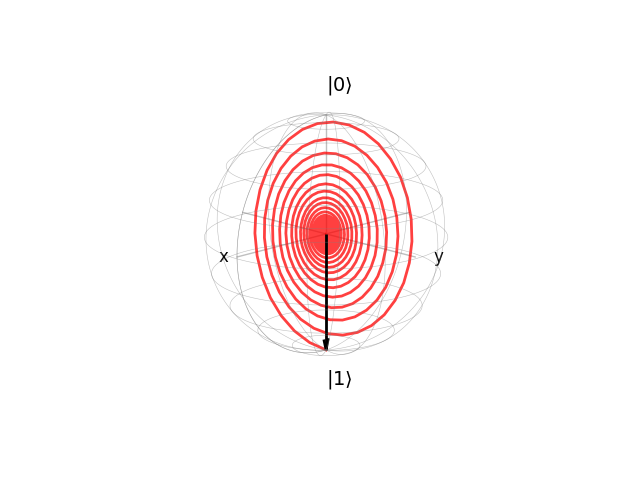

Figure saved in: ../../Results/Plot/Densification/90/AverageTrajectory_theta1p570796_dt0p010000


In [8]:

#visualization.plot_multiple_bloch_trajectories(many_rho[:N_traj_reduced], quiv_init=True, xylabels=True)
visualization.plot_multiple_bloch_trajectories(avg_many_rho, quiv_init=True, xylabels=True)

fig_avg_traj = plt.gcf()

filename_avg_traj = f"AverageTrajectory_theta{theta_str}_dt{dt_str}"

save_fig(fig_avg_traj, filename_avg_traj)

plt.close(fig_avg_traj)

In [9]:

plt.close('all')

fig_multi_bloch, axes = visualization.multi_figure_bloch_plot(n_subplots=4, ncols=2, xylabels=True, figsize=(15,10))

visualization.plot_onebloch_multipletrajectories(ax=axes[0], arrays=[avg_many_rho], alp=1,  quiv_init=True, rot_viev=(0, 0),  xylabels=True)
visualization.plot_onebloch_multipletrajectories(ax=axes[2], arrays=[avg_many_rho], alp=1,  quiv_init=True, rot_viev=(0, 90), xylabels=True, labels=[r'$\xi$'], showlegend=True)

visualization.plot_onebloch_multipletrajectories(ax=axes[1], arrays=many_rho[:N_traj_reduced], rot_viev=(0, 0),  xylabels=True, alp=0.1, colormap_plain=False, quiv_init=False, quiv=False, quiv_alpha=0.35 ) #title='dW') #cyan
visualization.plot_onebloch_multipletrajectories(ax=axes[3], arrays=many_rho[:N_traj_reduced], rot_viev=(0, 90), xylabels=True, alp=0.1, colormap_plain=False, quiv_init=False, quiv=False, quiv_alpha=0.35 ) #title='dW') 

plt.subplots_adjust(wspace=None, hspace=None)

filename_multi_bloch = f"MultiBlochGrid_theta{theta_str}_dt{dt_str}"

# Call your custom saving function
save_fig(fig_multi_bloch, filename_multi_bloch)

# Close the figure to free memory (crucial for cluster loops)
plt.close(fig_multi_bloch)

Figure saved in: ../../Results/Plot/Densification/90/MultiBlochGrid_theta1p570796_dt0p010000


## GIF

In [15]:
# ----------------------
# Path to save the GIFs
# ----------------------
path_gif_avg = os.path.join(Output_dir, f"bloch_avg_theta{theta_str}.gif")
path_gif_fading = os.path.join(Output_dir, f"bloch_fading_theta{theta_str}.gif")

# -------------------------------------
# 1. Slice and downsample trajectories
# -------------------------------------
# plot the first 10 trajectories
# take 1 time step every 50 
# array[trajectories, time_steps, rows, cols]
sampled_trajectories = many_rho[:10, :, :, :]
sampled_avg_trajectories = np.mean(sampled_trajectories, axis=0)

visualization.generate_bloch_animation(
    array=sampled_avg_trajectories,  # Input: The mean density matrix over time
    filename=path_gif_avg,           # Output: Full path including filename
    color='black',                   # Black color to distinguish the average
    fps=30,                   
    showit=False                     # VERY IMPORTANT: False prevents UI crashes on the cluster
)



MovieWriter ffmpeg unavailable; using Pillow instead.


Saved animation to ../../Results/Plot/Densification/0/bloch_avg_theta0p000000.gif


Saved animation to ../../Results/Plot/Densification/0/bloch_fading_theta0p000000.gif


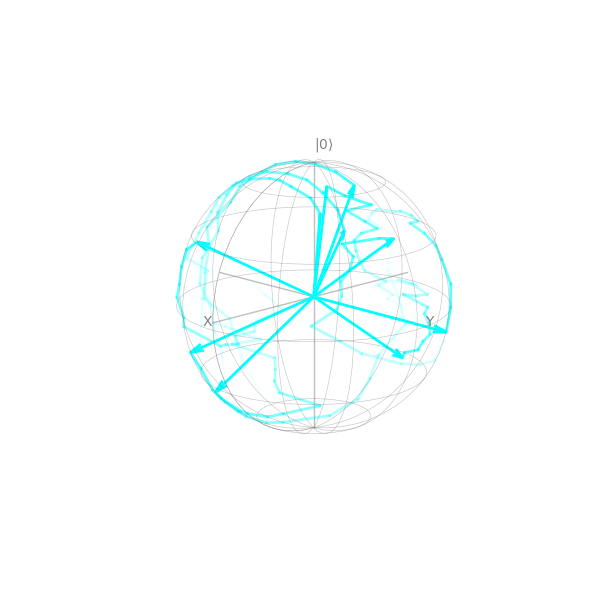

In [16]:
visualization.MULTI_FadingTrails_generate_bloch_animation(
    rho_list=sampled_trajectories,   # Pass the DOWNSAMPLED array
    filename=path_gif_fading,
    fps=20,
    colormap_use=True,               # Use gradient colors for the trajectories
    alp=0.75,
    trail_len=15,                    # Length of the comet tail (adjust based on new time steps)
    save_every_n=1,                   # Set to 1 because we ALREADY downsampled the array!
    colormap_plain=True,
    plaincolor='cyan'
)